In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

## VERİ YÜKLEME & ÖN İŞLEME

In [2]:
df = pd.read_csv("data/train.csv")

In [3]:
df.drop(columns=["PassengerId","Name","Ticket"],inplace=True)
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})
df["Cabin"] = df["Cabin"].notnull().astype(int)
df["Embarked"] = df["Embarked"].fillna(0)
df["Age"] = df["Age"].fillna(df["Age"].median())

In [4]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,0,22.0,1,0,7.2500,0,0.0
1,1,1,1,38.0,1,0,71.2833,1,1.0
2,1,3,1,26.0,0,0,7.9250,0,0.0
3,1,1,1,35.0,1,0,53.1000,1,0.0
4,0,3,0,35.0,0,0,8.0500,0,0.0


In [10]:
features = ["Pclass","Sex","Age","SibSp","Parch","Fare","Cabin","Embarked"]

X = df[features]
y = df["Survived"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Eğitim seti: {X_train.shape[0]} örnek")
print(f"Test  seti : {X_test.shape[0]} örnek\n")

Eğitim seti: 712 örnek
Test  seti : 179 örnek



## MODELİ EĞİT

In [11]:
dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    criterion="gini"    # "entropy" ile de dene
)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

## TAHMİN & DEĞERLENDİRME

In [14]:
y_pred = dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(confusion_matrix(y_test,y_pred))
print(f"Test Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=["Hayatta Kalmadı", "Hayatta Kaldı"]))

[[96  9]
 [27 47]]
Test Accuracy: 0.7989

Classification Report:
                 precision    recall  f1-score   support

Hayatta Kalmadı       0.78      0.91      0.84       105
  Hayatta Kaldı       0.84      0.64      0.72        74

       accuracy                           0.80       179
      macro avg       0.81      0.77      0.78       179
   weighted avg       0.80      0.80      0.79       179



## KARMAŞIKLIK MATRİSİ

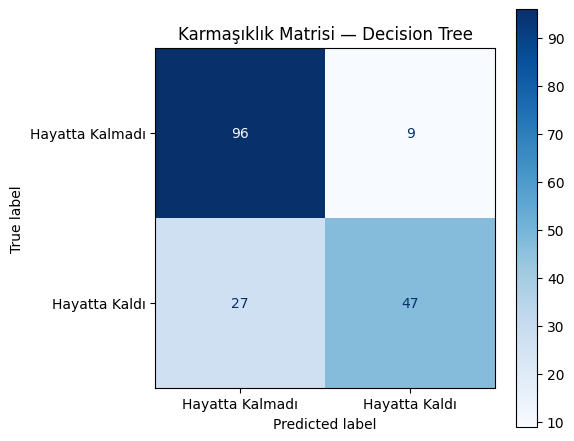

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Hayatta Kalmadı", "Hayatta Kaldı"],
    cmap="Blues", ax=ax
)
ax.set_title("Karmaşıklık Matrisi — Decision Tree")
plt.tight_layout()
plt.savefig("dt_confusion_matrix.png", dpi=150)
plt.show()

## KARAR AĞACI GÖRSELİ


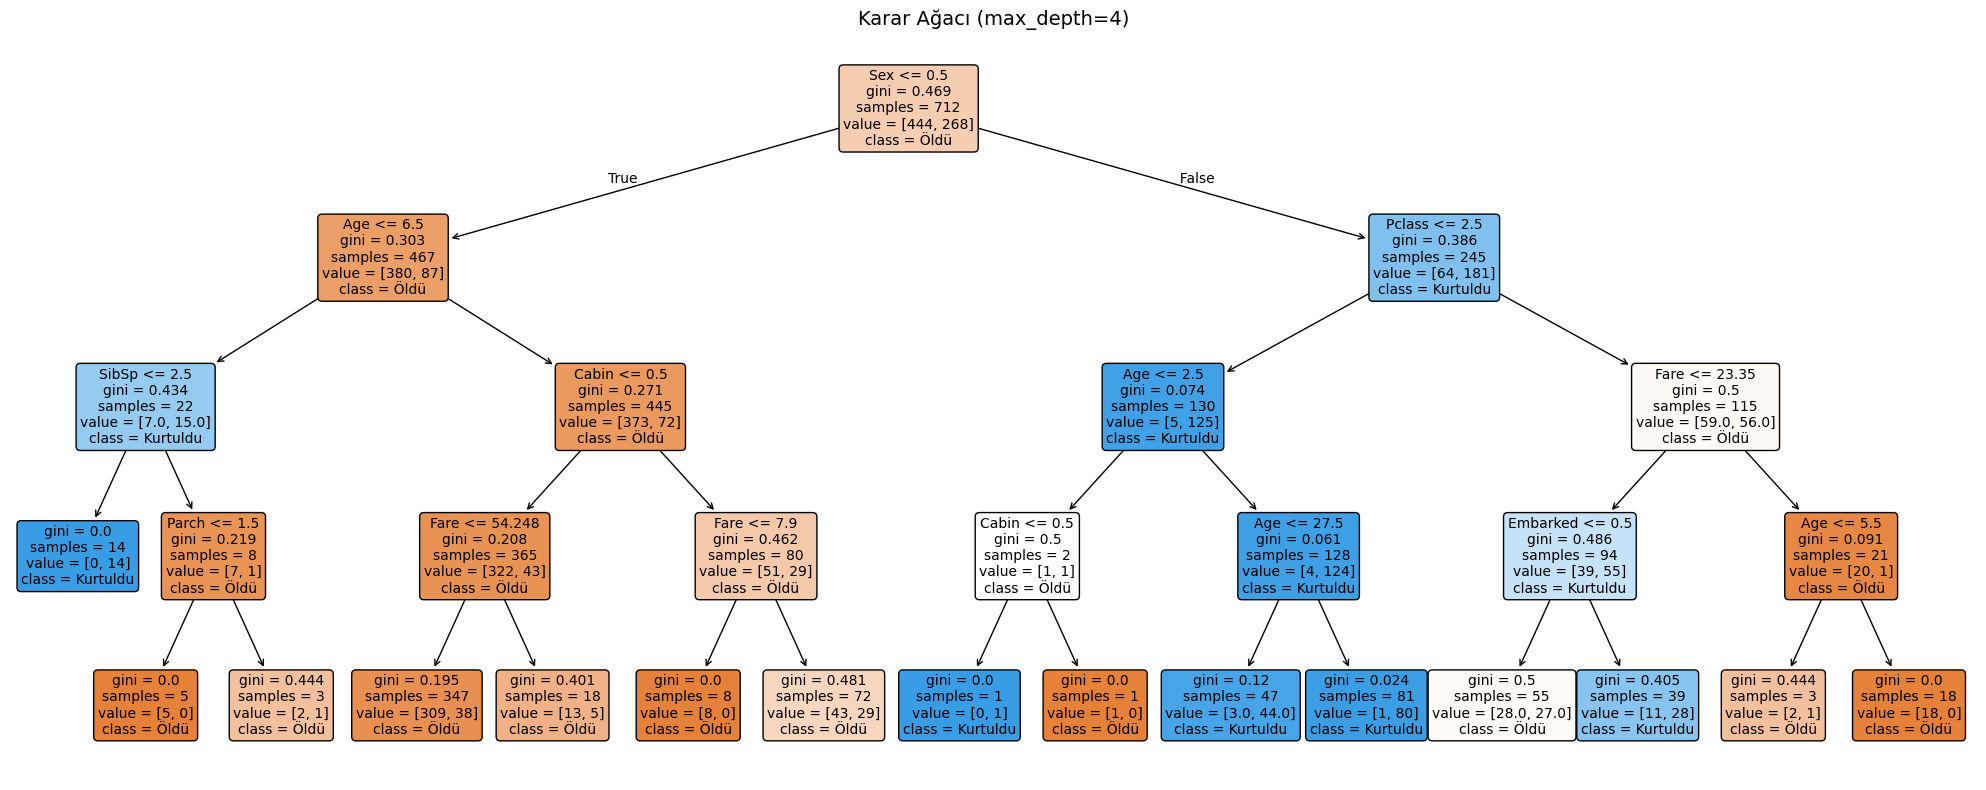

In [15]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=features,
    class_names=["Öldü", "Kurtuldu"],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title("Karar Ağacı (max_depth=4)", fontsize=14)
plt.tight_layout()
plt.savefig("dt_tree_plot.png", dpi=150)
plt.show()

In [17]:
print(export_text(dt, feature_names=features))

|--- Sex <= 0.50
|   |--- Age <= 6.50
|   |   |--- SibSp <= 2.50
|   |   |   |--- class: 1
|   |   |--- SibSp >  2.50
|   |   |   |--- Parch <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- Parch >  1.50
|   |   |   |   |--- class: 0
|   |--- Age >  6.50
|   |   |--- Cabin <= 0.50
|   |   |   |--- Fare <= 54.25
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  54.25
|   |   |   |   |--- class: 0
|   |   |--- Cabin >  0.50
|   |   |   |--- Fare <= 7.90
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  7.90
|   |   |   |   |--- class: 0
|--- Sex >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 2.50
|   |   |   |--- Cabin <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Cabin >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Age >  2.50
|   |   |   |--- Age <= 27.50
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  27.50
|   |   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Fare <= 23.35
|   |   |   |--- Embarked <= 0.50
|   |   |   |   |--- clas

## ÖZELLİK ÖNEMİ (Feature Importance)

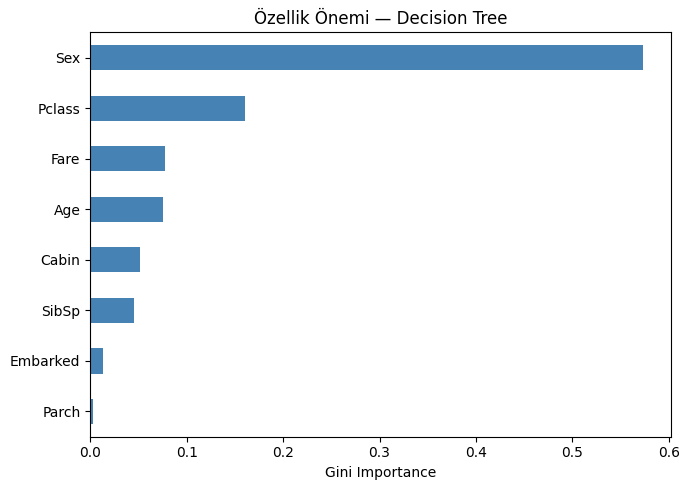

In [18]:
importances = pd.Series(dt.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("Özellik Önemi — Decision Tree")
ax.set_xlabel("Gini Importance")
plt.tight_layout()
plt.savefig("dt_feature_importance.png", dpi=150)
plt.show()

## OVERFITTING KONTROLÜ (Train vs Test accuracy karşılaştır)


In [19]:
train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"\nTrain Accuracy : {train_acc:.4f}")
print(f"Test  Accuracy : {test_acc:.4f}")
print(f"Fark           : {train_acc - test_acc:.4f}  ", end="")
print("(0.05'ten büyükse overfitting şüphesi!)\n")


Train Accuracy : 0.8371
Test  Accuracy : 0.7989
Fark           : 0.0382  (0.05'ten büyükse overfitting şüphesi!)



## MAX_DEPTH ARAMA — En iyi derinliği bul

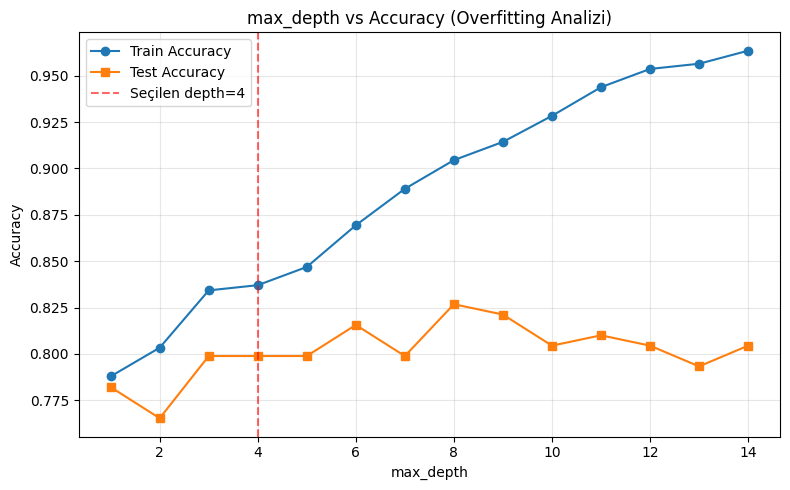

En iyi test accuracy → depth=8 (0.8268)


In [20]:
depths = range(1, 15)
train_scores, test_scores = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  model.predict(X_test)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, train_scores, "o-", label="Train Accuracy")
ax.plot(depths, test_scores,  "s-", label="Test Accuracy")
ax.axvline(x=4, color="red", linestyle="--", alpha=0.6, label="Seçilen depth=4")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("max_depth vs Accuracy (Overfitting Analizi)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dt_depth_search.png", dpi=150)
plt.show()

best_depth = depths[np.argmax(test_scores)]
print(f"En iyi test accuracy → depth={best_depth} "
      f"({max(test_scores):.4f})")

In [21]:
from sklearn.model_selection import cross_val_score
 
# Cross-Validation (5-Fold)
cv_scores_dt = cross_val_score(dt, X, y, cv=5, scoring="accuracy")
 
print(f"5-Fold CV Accuracy Skorları : {cv_scores_dt.round(4)}")
print(f"Ortalama                    : {cv_scores_dt.mean():.4f}")
print(f"Std Dev                     : {cv_scores_dt.std():.4f}")
 
dt_test_acc = accuracy_score(y_test, y_pred)
dt_cv_mean  = cv_scores_dt.mean()

5-Fold CV Accuracy Skorları : [0.7654 0.8258 0.809  0.7865 0.8427]
Ortalama                    : 0.8059
Std Dev                     : 0.0275
